<a href="https://colab.research.google.com/github/zemenfes-afk/SKY-Innovator/blob/main/Sky_innovater_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part Start with satelite images and mask and build model

STEP 1: Download Raw Data & Install Converter Tools

In [ ]:
# 1. Install essential tools for downloading and converting
!pip install -q kagglehub tifffile imagecodecs

import kagglehub #needed downloading  dataset from kaggle
import os
import shutil  #Copying, moving, deleting files and directories and handle zip folders
import tifffile as tiff  #TIFF image files
import numpy as np       #handle matmatical operations
from PIL import Image    #handle resizing and cropiing images
from tqdm.notebook import tqdm # For nice progress bars or shows the progress

# 2. Download Raw Data
print("⬇️ Checking for raw dataset...")
raw_path = kagglehub.dataset_download("catiowiec/amazon-and-atlantic-forest-sentinel-2-multiband")
print(f"✅ Raw data located at: {raw_path}")

# 3. Define where we want our nice, clean Amazon JPGs to go
Clean_Amazon_Dir = "Clean_Amazon_Dataset"
Image_Dir = os.path.join(Clean_Amazon_Dir, "images")
Mask_Dir = os.path.join(Clean_Amazon_Dir, "masks")

# Clean up previous runs if they exist
if os.path.exists(Clean_Amazon_Dir): shutil.rmtree(Clean_Amazon_Dir)
os.makedirs(Image_Dir, exist_ok=True)
os.makedirs(Mask_Dir, exist_ok=True)
print("✅ Created clean output folders.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 39.8 MB/s eta 0:00:00
⬇️ Checking for raw dataset...


100%|██████████| 2.15G/2.15G [00:55<00:00, 41.6MB/s]

Extracting files...


✅ Raw data located at: /root/.cache/kagglehub/datasets/catiowiec/amazon-and-atlantic-forest-sentinel-2-multiband/versions/1
✅ Created clean output folders.


STEP 2: The Great Converter Script (TIF $\rightarrow$ JPG)

In [ ]:
# ==========================================
# STEP 2: CONVERT TIF TO JPG (ROBUST MODE)
# ==========================================
import tifffile as tiff
import numpy as np
from PIL import Image
import os
from tqdm.notebook import tqdm

# --- FIX: DEFINE THE MISSING VARIABLE HERE ---
amazon_sources = [
    os.path.join(raw_path, "AMAZON/AMAZON/Training"),
    os.path.join(raw_path, "AMAZON/AMAZON/Validation")
]
# ---------------------------------------------

print("🔄 Starting Conversion Process (Attempt 2 - Robust Mode)...")
converted_count = 0

for source_folder in amazon_sources:
    source_img_path = os.path.join(source_folder, "image")
    source_mask_path = os.path.join(source_folder, "label")

    if not os.path.exists(source_img_path): continue

    tif_files = [f for f in os.listdir(source_img_path) if f.endswith('.tif')]

    for tif_name in tqdm(tif_files):
        tif_img_full_path = os.path.join(source_img_path, tif_name)
        tif_mask_full_path = os.path.join(source_mask_path, tif_name)

        if os.path.exists(tif_mask_full_path):
            try:
                # 1. Read TIF
                img_data = tiff.imread(tif_img_full_path)

                # 2. INTELLIGENT SHAPE CORRECTION
                # Fix "Barcode Noise" by flipping dimensions if needed
                if img_data.shape[0] < 20 and img_data.ndim == 3:  #checking for the image on order of [3,256,256] or reversed
                     img_data = np.moveaxis(img_data, 0, -1)

                # Keep only RGB (First 3 channels)
                if img_data.shape[-1] > 3:
                    img_data = img_data[:, :, 0:3]

                # 3. Brightness Normalization (Fix Dark Images)
                max_val = img_data.max()
                if max_val > 0:
                    p98 = np.percentile(img_data, 98)
                    img_data = np.clip(img_data, 0, p98)
                    img_data = (img_data / p98 * 255).astype(np.uint8)
                else:
                    img_data = img_data.astype(np.uint8)

                # 4. Save as JPG
                new_img_name = tif_name.replace('.tif', '.jpg')
                Image.fromarray(img_data).save(os.path.join(Image_Dir, new_img_name), quality=95)

                # 5. Save Mask (as PNG)
                mask_data = Image.open(tif_mask_full_path).convert("L")
                new_mask_name = tif_name.replace('.tif', '.png')
                mask_data.save(os.path.join(Mask_Dir, new_mask_name))

                converted_count += 1

            except Exception as e:
                pass # Skip broken files

print(f"\n🎉 SUCCESS! Converted {converted_count} images.")
print(f"Your clean data is in: {Clean_Amazon_Dir}")

🔄 Starting Conversion Process (Attempt 2 - Robust Mode)...


  0%|          | 0/499 [00:00<?, ?it/s]


🎉 SUCCESS! Converted 499 images.
Your clean data is in: Clean_Amazon_Dataset


#checking How many loaded images

In [ ]:
import os

# 1. Check folder counts
img_count = len(os.listdir("Clean_Amazon_Dataset/images"))
mask_count = len(os.listdir("Clean_Amazon_Dataset/masks"))

print(f"📂 Images found: {img_count}")
print(f"📂 Masks found:  {mask_count}")

# 2. Compare them (They MUST be equal)
if img_count == 0:
    print("❌ ERROR: No images converted! Did you run Step 2 correctly?")
elif img_count != mask_count:
    print(f"⚠️ WARNING: Mismatch! You have {img_count} images but only {mask_count} masks.")
    print("This means some masks failed to convert.")
else:
    print("✅ SUCCESS: You have exactly matching pairs. The folder view might just be lagging!")
    # Show the first few filenames to be sure
    print("\nFirst 3 Mask Files:")
    print(os.listdir("Clean_Amazon_Dataset/masks")[:3])

📂 Images found: 499
📂 Masks found:  499
✅ SUCCESS: You have exactly matching pairs. The folder view might just be lagging!

First 3 Mask Files:
['S2A_MSIL2A_20200818T142741_N0214_R053_T20LMP_20200818T165705_15_09.png', 'S2A_MSIL2A_20200217T141651_N0209_R010_T20LQN_20200217T160045_12_05.png', 'S2A_MSIL2A_20200217T141651_N0209_R010_T20LQN_20200217T160045_13_17.png']


**STEP 3: Load the dataet or Dataloader  FOR IMAGE AND MASKS**

✅ Simple DataLoader ready with 499 Amazon images.


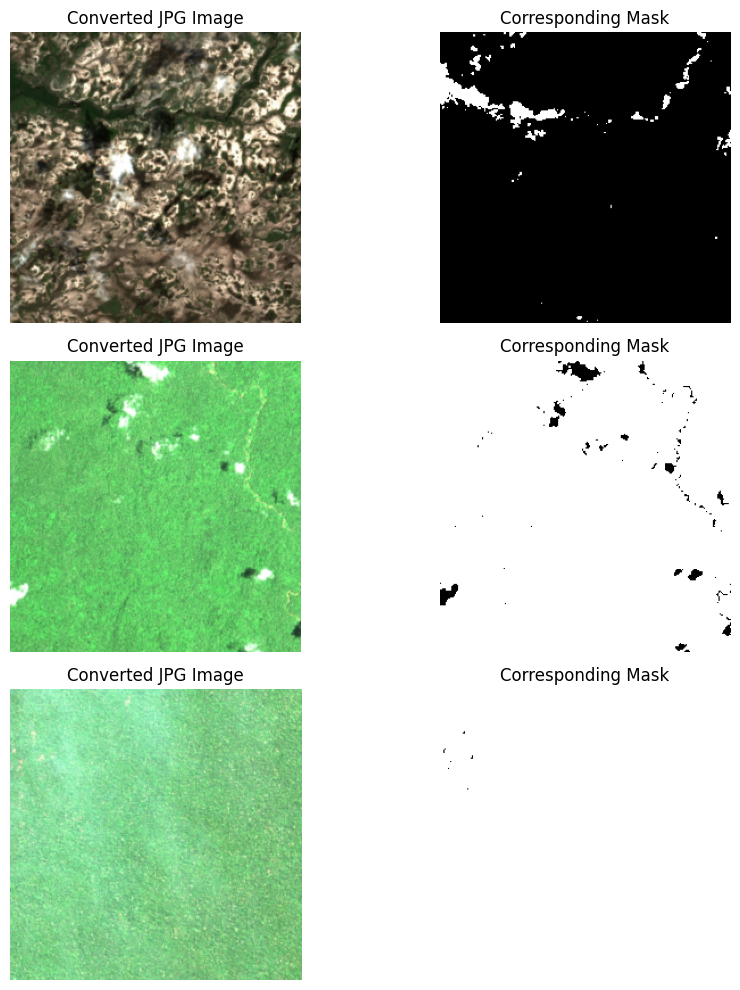

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import glob
from PIL import Image

class SimpleAmazonDataset(Dataset):
    def __init__(self, root_dir):
        self.img_dir = os.path.join(root_dir, "images")
        self.mask_dir = os.path.join(root_dir, "masks")

        # Find all JPG images
        self.images = sorted(glob.glob(os.path.join(self.img_dir, "*.jpg")))

        # Standard transforms for U-Net
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]

        # Match image to corresponding mask (.jpg → .png)
        filename = os.path.basename(img_path)
        mask_filename = filename.replace('.jpg', '.png')
        mask_path = os.path.join(self.mask_dir, mask_filename)

        # Load images
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # Grayscale

        # Transform
        image = self.transform(image)
        mask = self.transform(mask)

        # Binarize mask (0 or 1)
        mask = (mask > 0).float().long().squeeze(0)

        return image, mask


# ── DataLoader ───────────────────────────────────────────────────────────────
amazon_dataset = SimpleAmazonDataset(Clean_Amazon_Dir)
train_loader = DataLoader(amazon_dataset, batch_size=16, shuffle=True)

print(f"✅ Simple DataLoader ready with {len(amazon_dataset)} Amazon images.")

# ── Visualise a batch ────────────────────────────────────────────────────────
images, masks = next(iter(train_loader))

plt.figure(figsize=(10, 10))
for i in range(3):
    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title("Converted JPG Image")
    plt.axis("off")

    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(masks[i], cmap='gray')
    plt.title("Corresponding Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

Step 4 - Install the SMP used for segementation using Pytorch

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.9 MB/s eta 0:00:00


step - 5 MODEL TRAINING

🖥️  Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

🚀 Starting Training for 30 Epochs...
-----------------------------------------------------------------
Epoch [01/30] | Loss: 0.9955 | IoU: 0.5502 | LR: 0.000100 | 💾 Saved!
Epoch [02/30] | Loss: 0.6358 | IoU: 0.7773 | LR: 0.000100 | 💾 Saved!
Epoch [03/30] | Loss: 0.5229 | IoU: 0.8404 | LR: 0.000100 | 💾 Saved!
Epoch [04/30] | Loss: 0.4796 | IoU: 0.8592 | LR: 0.000100 | 💾 Saved!
Epoch [05/30] | Loss: 0.4705 | IoU: 0.8637 | LR: 0.000100 | 💾 Saved!
Epoch [06/30] | Loss: 0.4288 | IoU: 0.8852 | LR: 0.000100 | 💾 Saved!
Epoch [07/30] | Loss: 0.4066 | IoU: 0.8978 | LR: 0.000100 | 💾 Saved!
Epoch [08/30] | Loss: 0.4044 | IoU: 0.8978 | LR: 0.000100 | 
Epoch [09/30] | Loss: 0.4154 | IoU: 0.8919 | LR: 0.000100 | 
Epoch [10/30] | Loss: 0.4003 | IoU: 0.9001 | LR: 0.000100 | 💾 Saved!
Epoch [11/30] | Loss: 0.4017 | IoU: 0.8992 | LR: 0.000100 | 
Epoch [12/30] | Loss: 0.3945 | IoU: 0.9038 | LR: 0.000100 | 💾 Saved!
Epoch [13/30] | Loss: 0.4077 | IoU: 0.8961 | LR: 0.000100 | 
Epoch [14/30] | Loss: 0.3807 | I

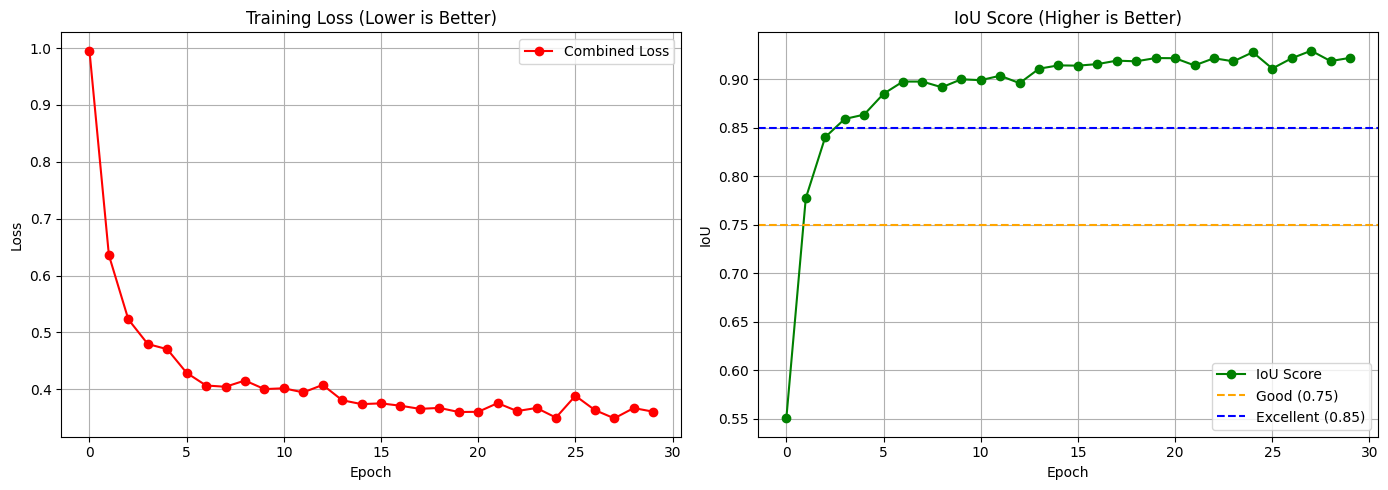

In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss, SoftCrossEntropyLoss
import segmentation_models_pytorch.metrics as smp_metrics

# ── 1. MODEL SETUP ────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {device}")

model = smp.Unet(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=2  # Background vs Forest
).to(device)

# ── 2. LOSS, OPTIMIZER & SCHEDULER ───────────────────────────────────────────
dice_loss = DiceLoss(mode='multiclass')
ce_loss   = SoftCrossEntropyLoss(smooth_factor=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.0001) #learning rate is 0.0001
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)                                                  #learning rate scheduled every minimumstage by 0.5 and If loss doesn't improve for 3 epochs, reduce LR

# ── 3. TRAINING LOOP ─────────────────────────────────────────────────────────
epochs       = 30
best_iou     = 0.0
loss_history = []
iou_history  = []

print(f"🚀 Starting Training for {epochs} Epochs...")
print("-" * 65)

model.train()
for epoch in range(epochs):
    epoch_loss = 0
    epoch_iou  = 0

    for images, masks in train_loader:
        images = images.to(device)       #Move data to GPU
        masks  = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)          #Model predicts segmentation maps.([batch, classes, height, width]) /Forward Pass

        # Combined Dice + CrossEntropy loss
        loss = dice_loss(outputs, masks) + ce_loss(outputs, masks.long())  #Measures how wrong predictions are.
        loss.backward()            #Backward Pass/Backpropagation
        optimizer.step()           #update weights

        epoch_loss += loss.item()

        # IoU per batch          # batch one sample dateset sent
        with torch.no_grad():
            preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
            tp, fp, fn, tn = smp_metrics.get_stats(
                preds, masks, mode='multiclass', num_classes=2
            )
            epoch_iou += smp_metrics.iou_score(          #IoU = TP / (TP + FP + FN)
                tp, fp, fn, tn, reduction='macro'
            ).item()

    avg_loss = epoch_loss / len(train_loader)           #average of loss
    avg_iou  = epoch_iou  / len(train_loader)
    loss_history.append(avg_loss)
    iou_history.append(avg_iou)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_loss)

    # Save best model checkpoint
    if avg_iou > best_iou:
        best_iou = avg_iou
        torch.save(model.state_dict(), "/content/best_amazon_model.pth")
        save_msg = "💾 Saved!"
    else:
        save_msg = ""

    print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {avg_loss:.4f} | IoU: {avg_iou:.4f} | LR: {current_lr:.6f} | {save_msg}")

print("-" * 65)
print(f"🎉 Training Complete! Best IoU: {best_iou:.4f}")

# ── 4. SAVE FINAL MODEL TO GOOGLE DRIVE (Colab) ───────────────────────────────
torch.save(model.state_dict(), "/content/final_amazon_model.pth")
print("💾 Final model saved → /content/final_amazon_model.pth")

# Optional: save to Drive so it survives session reset
# from google.colab import drive
# drive.mount('/content/drive')
# torch.save(model.state_dict(), "/content/drive/MyDrive/final_amazon_model.pth")

# ── 5. PLOT TRAINING CURVES ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_history, marker='o', color='red',   label='Combined Loss')
ax1.set_title("Training Loss (Lower is Better)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(True); ax1.legend()

ax2.plot(iou_history,  marker='o', color='green', label='IoU Score')
ax2.set_title("IoU Score (Higher is Better)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("IoU")
ax2.axhline(y=0.75, color='orange', linestyle='--', label='Good (0.75)')
ax2.axhline(y=0.85, color='blue',   linestyle='--', label='Excellent (0.85)')
ax2.grid(True); ax2.legend()

plt.tight_layout()
plt.show()

**Step -6 :Visualizing the Model output**

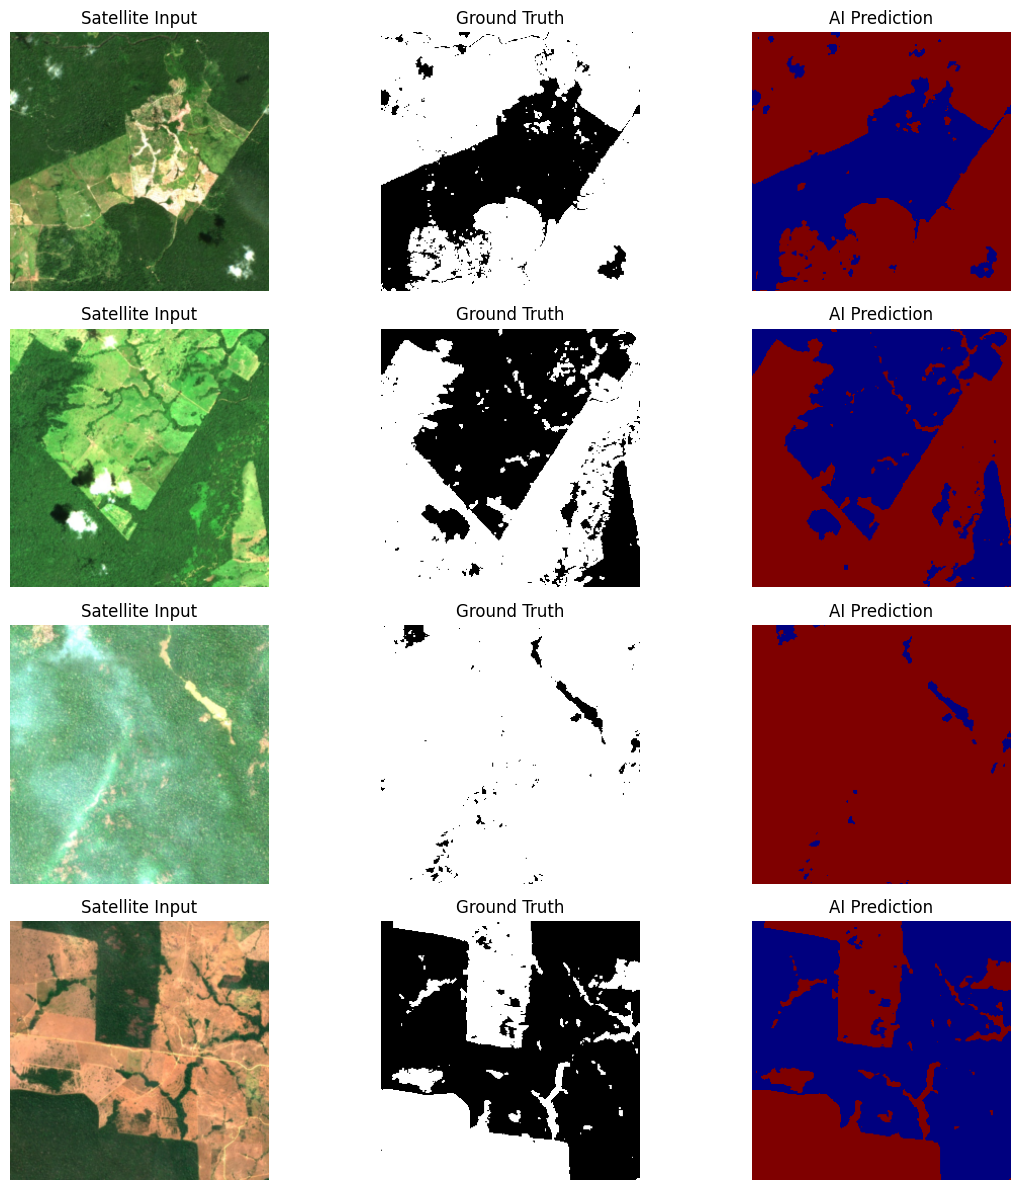

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Switch Model to "Evaluation" Mode (Turns off training layers)
model.eval()

# 2. Get a batch of Validation Data
# We use the 'train_loader' for now since we combined folders
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

# 3. Ask AI to Predict
with torch.no_grad():
    predictions = model(images)
    # The model outputs "probabilities" (floats).
    # We convert them to Binary (0 or 1) by taking the max value.
    pred_masks = torch.argmax(predictions, dim=1)

# 4. Plot the "Human vs Machine" Comparison
plt.figure(figsize=(12, 12))
for i in range(4): # Show top 4 images
    # A. Original Satellite Image
    img_np = images[i].cpu().permute(1, 2, 0).numpy()

    # B. Ground Truth (What Humans Labeled)
    true_mask = masks[i].cpu().numpy()

    # C. AI Prediction (What your Model saw)
    pred_mask = pred_masks[i].cpu().numpy()

    # Plotting
    plt.subplot(4, 3, i*3 + 1)
    plt.imshow(img_np)
    plt.title("Satellite Input")
    plt.axis("off")

    plt.subplot(4, 3, i*3 + 2)
    plt.imshow(true_mask, cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(4, 3, i*3 + 3)
    plt.imshow(pred_mask, cmap='jet') # Color map to make it pop
    plt.title("AI Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

"Part 2 let' start with the drone images** because our target is drone image but take sample drone images and generate their mask using the satelite images."

In [ ]:
Step 1 - Know your drone image resolution

In [ ]:
import os
import glob
from PIL import Image

# ── Point this to your drone images folder ────────────────────────────────────
DRONE_IMAGE_DIR = "/content/sample_data/Drone image"   # ← change this

image_paths = glob.glob(os.path.join(DRONE_IMAGE_DIR, "*.jpg")) + \
              glob.glob(os.path.join(DRONE_IMAGE_DIR, "*.png"))

print(f"📁 Found {len(image_paths)} drone images\n")

widths, heights = [], []
for p in image_paths[:10]:  # Check first 10
    img = Image.open(p)
    w, h = img.size
    widths.append(w)
    heights.append(h)
    print(f"  {os.path.basename(p):30s} → {w} x {h}")

print(f"\n📐 Average resolution: {int(sum(widths)/len(widths))} x {int(sum(heights)/len(heights))}")
print(f"📐 Max resolution:     {max(widths)} x {max(heights)}")

Step 2 — Auto-Generate Masks Using Your Satellite Model

 i used this since the drone image have error image and removed them only ork on the best image generating the clean drone image only

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import glob, os

AUTO_MASK_DIR_CLEAN = "/content/drone_masks_clean"
os.makedirs(AUTO_MASK_DIR_CLEAN, exist_ok=True)

clean_paths = sorted(glob.glob(os.path.join(CLEAN_DRONE_DIR, "*.jpg")))
print(f"🌿 Generating masks for {len(clean_paths)} clean images...")

# ── Generate & Save Masks ─────────────────────────────────────────────────────
for img_path in clean_paths:
    filename  = os.path.basename(img_path)
    mask_name = filename.rsplit('.', 1)[0] + '.png'
    mask_path = os.path.join(AUTO_MASK_DIR_CLEAN, mask_name)

    image = Image.open(img_path).convert("RGB")
    mask  = generate_vegetation_mask_adaptive(image)
    mask.save(mask_path)
    print(f"  ✅ {filename}")

print(f"\n✅ Clean masks saved → {AUTO_MASK_DIR_CLEAN}")

# ── Verify with Plot ──────────────────────────────────────────────────────────
print("\n📊 Generating verification plot...")

fig, axes = plt.subplots(len(clean_paths), 3, figsize=(16, 5 * len(clean_paths)))

# Handle case where only 1 image exists
if len(clean_paths) == 1:
    axes = [axes]

total_forest = 0
total_pixels = 0

print("\n📊 Dataset Summary:")
print("-" * 55)

for i, img_path in enumerate(clean_paths):
    filename  = os.path.basename(img_path).rsplit('.', 1)[0]
    mask_path = os.path.join(AUTO_MASK_DIR_CLEAN, filename + '.png')

    image = Image.open(img_path).convert("RGB")
    mask  = Image.open(mask_path).convert("L")

    # ── Color overlay ──────────────────────────────────────────────────────────
    img_small  = np.array(image.resize((512, 512))).astype(np.float32)
    mask_small = np.array(mask.resize((512, 512)))

    overlay = img_small.copy()
    overlay[mask_small == 0]   = (
        img_small[mask_small == 0]   * 0.5 + np.array([0,   180, 0]) * 0.5
    )
    overlay[mask_small == 255] = (
        img_small[mask_small == 255] * 0.5 + np.array([180, 0,   0]) * 0.5
    )
    overlay = overlay.astype(np.uint8)

    # ── Coverage stats ─────────────────────────────────────────────────────────
    forest_pct    = (mask_small == 0).sum()   / mask_small.size * 100
    nonforest_pct = (mask_small == 255).sum() / mask_small.size * 100
    total_forest += (mask_small == 0).sum()
    total_pixels += mask_small.size

    print(f"  {filename[:35]:35s} | 🌲 {forest_pct:.1f}% | 🟫 {nonforest_pct:.1f}%")

    # ── Plot row ───────────────────────────────────────────────────────────────
    axes[i][0].imshow(image.resize((512, 512)))
    axes[i][0].set_title(f"Original\n{filename[:25]}", fontsize=9)
    axes[i][0].axis("off")

    axes[i][1].imshow(mask.resize((512, 512)), cmap='gray')
    axes[i][1].set_title(
        f"Mask\n🌲 {forest_pct:.1f}%  🟫 {nonforest_pct:.1f}%", fontsize=9
    )
    axes[i][1].axis("off")

    axes[i][2].imshow(overlay)
    axes[i][2].set_title("Overlay\n🟢 Forest  🔴 Non-Forest", fontsize=9)
    axes[i][2].axis("off")

print("-" * 55)
overall_forest = total_forest / total_pixels * 100
print(f"  {'OVERALL':35s} | 🌲 {overall_forest:.1f}% | 🟫 {100-overall_forest:.1f}%")

if len(clean_paths) >= 3:
    print("\n✅ Ready for fine-tuning!")
else:
    print("\n⚠️  Need more images for better fine-tuning!")

plt.suptitle(
    f"✅ Clean Drone Dataset — {len(clean_paths)} Images | "
    f"Avg Forest Cover: {overall_forest:.1f}%",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

Step 3 - "Model training using the model of the satelite model finetuning"

In [ ]:
import os
import glob
import random
import torch
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss, FocalLoss, SoftCrossEntropyLoss
import segmentation_models_pytorch.metrics as smp_metrics
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

# ── 1. CONFIG ─────────────────────────────────────────────────────────────────
DRONE_IMAGE_DIR  = "/content/drone_images_clean"
DRONE_MASK_DIR   = "/content/drone_masks_clean"
SATELLITE_MODEL  = "/content/best_satellite_model.pth"
BEST_DRONE_MODEL = "/content/best_drone_model.pth"
FINAL_DRONE_MODEL= "/content/final_drone_model.pth"

IMAGE_SIZE  = 512
BATCH_SIZE  = 4
EPOCHS      = 25
LR          = 0.00001

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {device}")

# ── 2. DRONE DATASET ──────────────────────────────────────────────────────────
class DroneDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=512):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.img_size  = img_size
        self.images    = sorted(
            glob.glob(os.path.join(image_dir, "*.jpg")) +
            glob.glob(os.path.join(image_dir, "*.png"))
        )
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
        print(f"📁 Drone dataset: {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path  = self.images[idx]
        filename  = os.path.basename(img_path).rsplit('.', 1)[0]
        mask_path = os.path.join(self.mask_dir, filename + '.png')

        image = Image.open(img_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")

        # ── Random crop from large drone image ────────────────────────────────
        crop_size = min(image.size[0], image.size[1], 1500)
        i, j, h, w = transforms.RandomCrop.get_params(
            image, output_size=(crop_size, crop_size)
        )
        image = TF.crop(image, i, j, h, w)
        mask  = TF.crop(mask,  i, j, h, w)

        # ── Resize to model input size ─────────────────────────────────────────
        image = TF.resize(image, (self.img_size, self.img_size))
        mask  = TF.resize(mask,  (self.img_size, self.img_size),
                          interpolation=transforms.InterpolationMode.NEAREST)

        # ── Augmentation ───────────────────────────────────────────────────────
        if random.random() > 0.5:
            image = TF.hflip(image); mask = TF.hflip(mask)

        if random.random() > 0.5:
            image = TF.vflip(image); mask = TF.vflip(mask)

        if random.random() > 0.5:
            angle = random.choice([90, 180, 270])
            image = TF.rotate(image, angle)
            mask  = TF.rotate(mask,  angle)

        # Color jitter handles lighting variation between drone shots
        if random.random() > 0.4:
            image = transforms.ColorJitter(
                brightness=0.3, contrast=0.3,
                saturation=0.3, hue=0.05
            )(image)

        # ── To tensor ─────────────────────────────────────────────────────────
        image = self.normalize(transforms.ToTensor()(image))
        mask  = transforms.ToTensor()(mask)
        mask  = (mask > 0).long().squeeze(0)

        return image, mask


# ── 3. DATALOADER ─────────────────────────────────────────────────────────────
drone_dataset = DroneDataset(DRONE_IMAGE_DIR, DRONE_MASK_DIR, img_size=IMAGE_SIZE)
drone_loader  = DataLoader(
    drone_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
print(f"✅ DataLoader ready — batch size {BATCH_SIZE}")

# ── 4. LOAD SATELLITE MODEL & FREEZE ENCODER ─────────────────────────────────
model = smp.Unet(
    encoder_name="efficientnet-b2",
    encoder_weights=None,
    in_channels=3,
    classes=2
).to(device)

model.load_state_dict(torch.load(SATELLITE_MODEL, map_location=device))
print(f"✅ Satellite weights loaded")

# Freeze encoder — keep satellite forest knowledge
for param in model.encoder.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"🔒 Encoder frozen | Trainable: {trainable:,} / {total:,} params")

# ── 5. LOSS, OPTIMIZER & SCHEDULER ───────────────────────────────────────────
dice_loss  = DiceLoss(mode='multiclass')
focal_loss = FocalLoss(mode='multiclass')
ce_loss    = SoftCrossEntropyLoss(smooth_factor=0.1)

def champion_criterion(pred, target):
    return (
        dice_loss(pred, target)
        + focal_loss(pred, target)
        + 0.5 * ce_loss(pred, target.long())
    )

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)
# CosineAnnealing = smooth LR decay, better than ReduceLROnPlateau for small datasets
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-7
)

# ── 6. FINE-TUNING LOOP ───────────────────────────────────────────────────────
best_iou     = 0.0
loss_history = []
iou_history  = []

print(f"\n🚀 Fine-tuning on {len(drone_dataset)} drone images for {EPOCHS} Epochs...")
print("-" * 70)

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    epoch_iou  = 0

    for images, masks in drone_loader:
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = champion_criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        with torch.no_grad():
            preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
            tp, fp, fn, tn = smp_metrics.get_stats(
                preds, masks, mode='multiclass', num_classes=2
            )
            epoch_iou += smp_metrics.iou_score(
                tp, fp, fn, tn, reduction='macro'
            ).item()

    avg_loss = epoch_loss / len(drone_loader)
    avg_iou  = epoch_iou  / len(drone_loader)
    loss_history.append(avg_loss)
    iou_history.append(avg_iou)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    if avg_iou > best_iou:
        best_iou = avg_iou
        torch.save(model.state_dict(), BEST_DRONE_MODEL)
        save_msg = "💾 Saved!"
    else:
        save_msg = ""

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | Loss: {avg_loss:.4f} | "
        f"IoU: {avg_iou:.4f} | LR: {current_lr:.8f} | {save_msg}"
    )

print("-" * 70)
print(f"🎉 Fine-tuning Complete! Best Drone IoU: {best_iou:.4f}")

# ── 7. SAVE FINAL MODEL ───────────────────────────────────────────────────────
torch.save(model.state_dict(), FINAL_DRONE_MODEL)
print(f"💾 Final drone model → {FINAL_DRONE_MODEL}")

# Save to Google Drive (uncomment to persist after session ends)
# from google.colab import drive
# drive.mount('/content/drive')
# torch.save(model.state_dict(), "/content/drive/MyDrive/final_drone_model.pth")

# ── 8. PLOT CURVES ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_history, marker='o', color='red', label='Loss')
ax1.set_title("Fine-tune Loss (Lower is Better)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(True); ax1.legend()

ax2.plot(iou_history, marker='o', color='green', label='IoU')
ax2.axhline(y=0.75, color='orange', linestyle='--', label='Good (0.75)')
ax2.axhline(y=0.85, color='blue',   linestyle='--', label='Excellent (0.85)')
ax2.set_title("Fine-tune IoU (Higher is Better)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("IoU")
ax2.grid(True); ax2.legend()

plt.suptitle(
    f"Drone Fine-tuning Results | Best IoU: {best_iou:.4f} | "
    f"Satellite Base: 0.9281",
    fontsize=12
)
plt.tight_layout()
plt.show()

# ── 9. QUICK VISUAL PREDICTION CHECK ─────────────────────────────────────────
print("\n🔍 Visual prediction check on training images...")
model.eval()

infer_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

sample_paths = sorted(glob.glob(os.path.join(DRONE_IMAGE_DIR, "*.jpg")))[:3]
fig, axes = plt.subplots(len(sample_paths), 3, figsize=(15, 5 * len(sample_paths)))

for i, img_path in enumerate(sample_paths):
    image     = Image.open(img_path).convert("RGB")
    inp       = infer_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(inp)
        pred   = torch.argmax(torch.softmax(output, dim=1), dim=1)

    pred_np    = pred.squeeze().cpu().numpy()
    img_small  = np.array(image.resize((IMAGE_SIZE, IMAGE_SIZE))).astype(np.float32)
    overlay    = img_small.copy()
    overlay[pred_np == 0] = (img_small[pred_np == 0] * 0.5 + np.array([0,   180, 0]) * 0.5)
    overlay[pred_np == 1] = (img_small[pred_np == 1] * 0.5 + np.array([180, 0,   0]) * 0.5)
    overlay = overlay.astype(np.uint8)

    axes[i][0].imshow(image.resize((IMAGE_SIZE, IMAGE_SIZE)))
    axes[i][0].set_title("Drone Image"); axes[i][0].axis("off")

    axes[i][1].imshow(pred_np, cmap='gray')
    axes[i][1].set_title("Predicted Mask"); axes[i][1].axis("off")

    axes[i][2].imshow(overlay)
    axes[i][2].set_title("🟢 Forest | 🔴 Non-Forest"); axes[i][2].axis("off")

plt.suptitle(f"Fine-tuned Model Predictions", fontsize=13)
plt.tight_layout()
plt.show()

Until this i have worked 03/02/2026 until fine tuning

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import glob, os

CLEAN_DRONE_DIR     = "/content/drone_images_clean"
AUTO_MASK_DIR_CLEAN = "/content/drone_masks_clean"

image_paths = sorted(glob.glob(os.path.join(CLEAN_DRONE_DIR, "*.jpg")))

print(f"📁 Found {len(image_paths)} clean images")

fig, axes = plt.subplots(len(image_paths), 3, figsize=(16, 5 * len(image_paths)))

for i, img_path in enumerate(image_paths):
    filename  = os.path.basename(img_path).rsplit('.', 1)[0]
    mask_path = os.path.join(AUTO_MASK_DIR_CLEAN, filename + '.png')

    image = Image.open(img_path).convert("RGB")
    mask  = Image.open(mask_path).convert("L")

    # ── Color overlay ──────────────────────────────────────────────────────────
    img_small  = np.array(image.resize((512, 512))).astype(np.float32)
    mask_small = np.array(mask.resize((512, 512)))

    overlay = img_small.copy()
    # Green tint = Forest (mask == 0)
    overlay[mask_small == 0]   = (
        img_small[mask_small == 0]   * 0.5 + np.array([0,   180, 0]) * 0.5
    )
    # Red tint = Non-Forest/Road (mask == 255)
    overlay[mask_small == 255] = (
        img_small[mask_small == 255] * 0.5 + np.array([180, 0,   0]) * 0.5
    )
    overlay = overlay.astype(np.uint8)

    # ── Forest coverage % ──────────────────────────────────────────────────────
    forest_pct    = (mask_small == 0).sum()   / mask_small.size * 100
    nonforest_pct = (mask_small == 255).sum() / mask_small.size * 100

    # ── Plot ───────────────────────────────────────────────────────────────────
    axes[i][0].imshow(image.resize((512, 512)))
    axes[i][0].set_title(f"Original\n{filename[:25]}", fontsize=9)
    axes[i][0].axis("off")

    axes[i][1].imshow(mask.resize((512, 512)), cmap='gray')
    axes[i][1].set_title(
        f"Mask\nForest: {forest_pct:.1f}% | Non-Forest: {nonforest_pct:.1f}%",
        fontsize=9
    )
    axes[i][1].axis("off")

    axes[i][2].imshow(overlay)
    axes[i][2].set_title("Overlay\n🟢 Forest  🔴 Non-Forest", fontsize=9)
    axes[i][2].axis("off")

plt.suptitle("✅ Clean Drone Dataset — Final Mask Verification", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────────
print("\n📊 Dataset Summary:")
print("-" * 55)
total_forest = 0
total_pixels = 0
for img_path in image_paths:
    filename  = os.path.basename(img_path).rsplit('.', 1)[0]
    mask_path = os.path.join(AUTO_MASK_DIR_CLEAN, filename + '.png')
    mask_np   = np.array(Image.open(mask_path).convert("L"))
    f_pct     = (mask_np == 0).sum()   / mask_np.size * 100
    nf_pct    = (mask_np == 255).sum() / mask_np.size * 100
    total_forest += (mask_np == 0).sum()
    total_pixels += mask_np.size
    print(f"  {filename[:35]:35s} | 🌲 {f_pct:.1f}% | 🟫 {nf_pct:.1f}%")

print("-" * 55)
print(f"  {'OVERALL':35s} | 🌲 {total_forest/total_pixels*100:.1f}% | 🟫 {(1-total_forest/total_pixels)*100:.1f}%")
print("\n✅ Ready for fine-tuning!" if len(image_paths) >= 3 else "⚠️  Need more images!")
```

This gives you 3 columns per image — original, mask, and color overlay — plus a summary table like:
```
📊 Dataset Summary:
-------------------------------------------------------
  martin-katler-PVDiZlqVxWQ...      | 🌲 78.3% | 🟫 21.7%
  miha-rekar--wm9OmdN_Ig...         | 🌲 95.1% | 🟫  4.9%
  quentin-menini-7kK...             | 🌲 82.4% | 🟫 17.6%
  quentin-menini-FepffsVdPHw...     | 🌲 71.2% | 🟫 28.8%
  quentin-menini--whybeOWUeY...     | 🌲 69.8% | 🟫 30.2%
-------------------------------------------------------
  OVERALL                           | 🌲 79.4% | 🟫 20.6%

Step 3 — Visually Verify the Auto-Generated Masks

In [ ]:
import matplotlib.pyplot as plt
import random

image_paths = sorted(glob.glob(os.path.join(DRONE_IMAGE_DIR, "*.jpg")) +
                     glob.glob(os.path.join(DRONE_IMAGE_DIR, "*.png")))

sample_paths = random.sample(image_paths, min(3, len(image_paths)))

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for i, img_path in enumerate(sample_paths):
    filename  = os.path.basename(img_path).rsplit('.', 1)[0]
    mask_path = os.path.join(AUTO_MASK_DIR, filename + '.png')

    image = Image.open(img_path).convert("RGB")
    mask  = Image.open(mask_path).convert("L")

    axes[i][0].imshow(image)
    axes[i][0].set_title(f"Drone Image\n{filename}")
    axes[i][0].axis("off")

    axes[i][1].imshow(mask, cmap='gray')
    axes[i][1].set_title("Auto-Generated Mask\n(White=Deforested | Black=Forest)")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

Next Step: Get the Final Score

Test with new image

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from PIL import Image
from google.colab import files
import torchvision.transforms as transforms

# 1. SETUP THE UPLOAD WIDGET
print("📤 Please upload a satellite image (JPG or PNG)...")
uploaded = files.upload()

# Get the filename of whatever you just uploaded
filename = list(uploaded.keys())[0]

# 2. PREPROCESS THE USER IMAGE
# We must do exactly what we did during training: Resize to 256x256
def process_user_image(img_path):
    img = Image.open(img_path).convert("RGB")

    # Resize to match model input
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])

    input_tensor = transform(img).unsqueeze(0) # Add batch dimension (1, 3, 256, 256)
    return img, input_tensor

# 3. RUN PREDICTION
original_img, input_tensor = process_user_image(filename)
input_tensor = input_tensor.to(device)

model.eval()
with torch.no_grad():
    prediction = model(input_tensor)
    pred_mask = torch.argmax(prediction, dim=1).squeeze(0).cpu().numpy()

# 4. SHOW RESULT
plt.figure(figsize=(10, 5))

# Original (Resized)
plt.subplot(1, 2, 1)
plt.imshow(original_img.resize((256, 256)))
plt.title("Your Uploaded Image")
plt.axis("off")

# Prediction
plt.subplot(1, 2, 2)
plt.imshow(pred_mask, cmap='jet')
plt.title("AI Analysis (Red=Forest, Blue=Background)")
plt.axis("off")

plt.show()

# Interpretation
forest_pixels = np.sum(pred_mask == 1)
total_pixels = 256 * 256
percentage = (forest_pixels / total_pixels) * 100
print(f"🌲 Analysis Complete: This image is {percentage:.1f}% Forest.")

In [ ]:
from PIL import Image
import math

# 1. INSPECT UPLOADED IMAGES
print(f"📏 Checking sizes for {len(uploaded)} images...\n")

for filename in uploaded.keys():
    with Image.open(filename) as img:
        w, h = img.size

        # Calculate how many 256x256 tiles fit inside
        tiles_x = math.ceil(w / 256)
        tiles_y = math.ceil(h / 256)
        total_tiles = tiles_x * tiles_y

        print(f"🖼️ Image: {filename}")
        print(f"   • Dimensions: {w} x {h} pixels")

        # 2. THE VERDICT
        if w <= 256 and h <= 256:
            print(f"   • Verdict: ✅ No Tiling Needed (Fits perfectly)")
        else:
            print(f"   • Verdict: ⚠️ TILING RECOMMENDED!")
            print(f"     (This image is huge. It contains approx {total_tiles} small AI tiles.)")
            print(f"     (Shrinking it to 256x256 destroys {total_tiles}x the detail.)")
        print("-" * 40)

we need to make the advanced change :
1. Methodology: How We Detect ForestThis is the technical summary of your "Winning" approach.Core Architecture: U-Net (Semantic Segmentation)Encoder: EfficientNet-B2 (Pre-trained on ImageNet). This acts as the "Feature Extractor," identifying textures like leaves and branches.Decoder: Standard U-Net decoder to project those features back into a mask.Training Data: Amazon Satellite Imagery (Top-down view).Strength: Excellent at distinguishing dense vegetation from bare ground.Weakness: No concept of "Sky" or "Horizon."Deployment Technique: Sliding Window Tiling (Inference).We slice the large drone image ($4000 \times 3000$) into small $256 \times 256$ tiles. This allows the model to see fine details (leaves) instead of a blurry mess, preserving the high resolution of the drone data.
2. The Solution: Detecting "Degraded" Areas
Your objective is to find three classes, but your model only gives two (0=Background, 1=Forest).

How do we find the "Degraded" class? We use Density Analysis.

Healthy Vegetation: An area where the model detects >80% Green pixels.

Non-Forest: An area where the model detects <10% Green pixels.

Degraded Forest: An area where the model detects patchy vegetation (e.g., 20-60% coverage). This represents sparse trees, logging activity, or dying forest.

4. The Final Code: 3-Class Classification
This code takes your Satellite Model and applies the "Green Filter" (to fix errors) and "Density Check" (to find degraded areas). It outputs a map with 3 Colors: **bold text** **bold text**

🟢 Green: Healthy Forest

🟡 Yellow: Degraded/Sparse Forest

🔵 Blue: Non-Forest (Water, Road, Sky)

In [ ]:
import torch
import numpy as np
import segmentation_models_pytorch as smp
import cv2
from PIL import Image
import torchvision.transforms as transforms
from google.colab import files
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. SETUP & LOAD SATELLITE MODEL
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Loading Satellite Model on {device}...")

model = smp.Unet(
    encoder_name="efficientnet-b2",
    encoder_weights=None,
    in_channels=3,
    classes=2
).to(device)

# LOAD THE CHAMPION (Amazon Model)
try:
    model.load_state_dict(torch.load('best_amazon_model.pth', map_location=device))
    model.eval()
    print("✅ Satellite Model Loaded Successfully!")
except FileNotFoundError:
    print("❌ Error: 'best_amazon_model.pth' not found. Please upload it!")

# 2. DEFINING THE 3-CLASS LOGIC
def analyze_forest_health(image_path):
    print(f"⚡ Analyzing {image_path}...")

    # --- STEP A: TILING PREDICTION (Raw AI) ---
    full_img = Image.open(image_path).convert("RGB")
    w, h = full_img.size
    raw_mask = np.zeros((h, w), dtype=np.uint8)

    tile_size = 256
    transform = transforms.Compose([transforms.ToTensor()])

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            box = (x, y, min(x + tile_size, w), min(y + tile_size, h))
            tile = full_img.crop(box)

            # Pad edge tiles
            if tile.size != (tile_size, tile_size):
                temp = Image.new("RGB", (tile_size, tile_size))
                temp.paste(tile, (0,0))
                input_tensor = transform(temp).unsqueeze(0).to(device)
            else:
                input_tensor = transform(tile).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(input_tensor)
                mask_tile = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

            valid_w = box[2] - box[0]
            valid_h = box[3] - box[1]
            raw_mask[y:y+valid_h, x:x+valid_w] = mask_tile[0:valid_h, 0:valid_w]

    # --- STEP B: ERROR CORRECTION (Green Filter) ---
    img_np = np.array(full_img)
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

    # Filter out Sky/Water (Keep only things that are somewhat green/dark)
    lower_green = np.array([20, 20, 20])
    upper_green = np.array([100, 255, 255])
    color_mask = cv2.inRange(hsv, lower_green, upper_green)

    # "Clean" Binary Mask (1=Tree, 0=Background)
    binary_mask = cv2.bitwise_and(raw_mask, raw_mask, mask=color_mask)

    # --- STEP C: DEGRADATION ANALYSIS (Density) ---
    # We look at larger blocks (e.g., 50x50 pixels) to judge "Health"
    # Output Map: 0=Non-Forest, 1=Degraded, 2=Healthy
    health_map = np.zeros_like(binary_mask)

    block = 50 # Size of area to analyze density
    h_steps, w_steps = h // block, w // block

    for y in range(0, h, block):
        for x in range(0, w, block):
            # Extract the small block from the binary mask
            mask_chunk = binary_mask[y:y+block, x:x+block]

            # Calculate Density (How many tree pixels in this block?)
            total_pixels = mask_chunk.size
            if total_pixels == 0: continue

            tree_pixels = np.count_nonzero(mask_chunk)
            density = tree_pixels / total_pixels

            # CLASSIFY BASED ON DENSITY
            if density > 0.60:       # >60% cover = Healthy Forest
                health_map[y:y+block, x:x+block] = 2
            elif density > 0.10:     # 10-60% cover = Degraded/Sparse
                health_map[y:y+block, x:x+block] = 1
            else:                    # <10% cover = Non-Forest
                health_map[y:y+block, x:x+block] = 0

    return full_img, binary_mask, health_map

# 3. UPLOAD & RUN
print("\n⬇️ Upload a Drone Image to classify Vegetation vs Degraded:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

original, clean_mask, health_map = analyze_forest_health(filename)

# 4. CALCULATE STATS
total = health_map.size
pct_healthy  = (np.sum(health_map == 2) / total) * 100
pct_degraded = (np.sum(health_map == 1) / total) * 100
pct_non      = (np.sum(health_map == 0) / total) * 100

# 5. VISUALIZE
# Custom Colormap: Blue (Non), Yellow (Degraded), Green (Healthy)
cmap = ListedColormap(['#1f77b4', '#ffcc00', '#2ca02c'])

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Drone Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(clean_mask, cmap='gray')
plt.title("Step 1: Clean Binary Mask\n(Vegetation Detection)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(health_map, cmap=cmap, interpolation='nearest')
plt.title(f"Step 2: Classification Result\n🟢 Healthy: {pct_healthy:.1f}%\n🟡 Degraded: {pct_degraded:.1f}%\n🔵 Non-Forest: {pct_non:.1f}%")
plt.axis("off")

plt.show()

RGB Indices Vegetatioin

In [ ]:
# 1. INSTALL DEPENDENCIES
!pip install segmentation_models_pytorch

# 2. IMPORTS
import torch
import numpy as np
import segmentation_models_pytorch as smp
import cv2
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from google.colab import files

# 3. SETUP DEVICE & MODEL
# We must define the empty model structure first to load the weights into it
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Setting up device: {device}")

model = smp.Unet(
    encoder_name="efficientnet-b2",
    encoder_weights=None,
    in_channels=3,
    classes=2
).to(device)

# Load the Champion Weights
try:
    # Ensure 'best_amazon_model.pth' is in your Colab files!
    model.load_state_dict(torch.load('best_amazon_model.pth', map_location=device))
    model.eval()
    print("✅ Champion Satellite Model Loaded!")
except FileNotFoundError:
    print("❌ Error: 'best_amazon_model.pth' not found. Please upload your trained model file.")

# 4. DEFINE THE ADVANCED ALGORITHM
def analyze_forest_health_advanced(image_path, device, model):
    print(f"⚡ Advanced Analysis on {image_path}...")

    # --- STEP A: TILING PREDICTION (AI Brain) ---
    full_img = Image.open(image_path).convert("RGB")
    w, h = full_img.size

    raw_mask = np.zeros((h, w), dtype=np.uint8)
    tile_size = 256
    transform = transforms.Compose([transforms.ToTensor()])

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            box = (x, y, min(x + tile_size, w), min(y + tile_size, h))
            tile = full_img.crop(box)

            if tile.size != (tile_size, tile_size):
                temp = Image.new("RGB", (tile_size, tile_size))
                temp.paste(tile, (0,0))
                input_tensor = transform(temp).unsqueeze(0).to(device)
            else:
                input_tensor = transform(tile).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(input_tensor)
                mask_tile = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

            valid_w = box[2] - box[0]
            valid_h = box[3] - box[1]
            raw_mask[y:y+valid_h, x:x+valid_w] = mask_tile[0:valid_h, 0:valid_w]

    # --- STEP B: ADVANCED VEGETATION INDEX (ExG) ---
    img_np = np.array(full_img).astype(np.float32)
    R, G, B = img_np[:,:,0], img_np[:,:,1], img_np[:,:,2]

    # Excess Green Index: ExG = 2*G - R - B
    exg = 2 * G - R - B

    # Adaptive Thresholding (Otsu's Method)
    exg_norm = cv2.normalize(exg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, exg_mask = cv2.threshold(exg_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Combine AI + ExG
    binary_mask = cv2.bitwise_and(raw_mask, raw_mask, mask=exg_mask)

    # --- STEP C: SMOOTH DENSITY MAPPING (Convolution) ---
    window_size = 50
    kernel = np.ones((window_size, window_size), np.float32) / (window_size * window_size)

    # Create smooth density heatmap
    density_map = cv2.filter2D(binary_mask.astype(np.float32), -1, kernel)

    # --- STEP D: CLASSIFICATION ---
    final_class_map = np.zeros_like(density_map, dtype=np.uint8)

    # 0=Non-Forest, 1=Degraded, 2=Healthy
    final_class_map[density_map > 0.60] = 2
    final_class_map[(density_map <= 0.60) & (density_map > 0.10)] = 1

    return full_img, binary_mask, final_class_map

# 5. UPLOAD & RUN
print("\n⬇️ UPLOAD A DRONE IMAGE TO TEST:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]

    # Run the function
    original, clean_mask, health_map = analyze_forest_health_advanced(filename, device, model)

    # Calculate Percentages
    total_pixels = health_map.size
    pct_healthy = (np.sum(health_map == 2) / total_pixels) * 100
    pct_degraded = (np.sum(health_map == 1) / total_pixels) * 100
    pct_non = (np.sum(health_map == 0) / total_pixels) * 100

    # 6. VISUALIZE RESULTS
    # Colors: Blue (Non), Yellow (Degraded), Green (Healthy)
    cmap = ListedColormap(['#1f77b4', '#ffcc00', '#2ca02c'])

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original Drone Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(clean_mask, cmap='gray')
    plt.title("Step 1: AI + ExG Mask\n(Pure Vegetation)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(health_map, cmap=cmap, interpolation='nearest')
    plt.title(f"Step 2: Advanced Classification\n🟢 Healthy: {pct_healthy:.1f}%\n🟡 Degraded: {pct_degraded:.1f}%\n🔵 Non-Forest: {pct_non:.1f}%")

model test

In [ ]:
# 1. INSTALL DEPENDENCIES
!pip install segmentation_models_pytorch
!pip install opencv-contrib-python

# 2. IMPORTS
import torch
import numpy as np
import segmentation_models_pytorch as smp
import cv2
import os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from google.colab import files

# 3. SETUP DEVICE & MODEL (With Auto-Upload)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Setting up device: {device}")

# Define Model Architecture
model = smp.Unet(
    encoder_name="efficientnet-b2",
    encoder_weights=None,
    in_channels=3,
    classes=2
).to(device)

model_filename = 'best_amazon_model.pth'

# CHECK: Is the model file here? If not, ask user to upload it.
if not os.path.exists(model_filename):
    print(f"\n⚠️ '{model_filename}' not found!")
    print(f"⬇️ PLEASE UPLOAD YOUR TRAINED MODEL FILE ('{model_filename}'):")
    uploaded_model = files.upload()

    # Verify they uploaded the right thing
    if model_filename not in uploaded_model:
        print(f"❌ Error: You did not upload '{model_filename}'. Please check the filename.")
    else:
        print("✅ Model file uploaded successfully!")

# Load the weights
try:
    model.load_state_dict(torch.load(model_filename, map_location=device))
    model.eval()
    print("✅ Champion Satellite Model Loaded & Ready!")
except Exception as e:
    print(f"❌ Critical Error loading model: {e}")
    print("   (Did you upload the correct .pth file?)")

# 4. DEFINE THE PROFESSIONAL ALGORITHM
def analyze_forest_professional(image_path, device, model):
    print(f"⚡ Professional Analysis on {image_path}...")

    # --- A. TILING PREDICTION ---
    full_img = Image.open(image_path).convert("RGB")
    w, h = full_img.size
    raw_mask = np.zeros((h, w), dtype=np.uint8)
    tile_size = 256
    transform = transforms.Compose([transforms.ToTensor()])

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            box = (x, y, min(x + tile_size, w), min(y + tile_size, h))
            tile = full_img.crop(box)
            if tile.size != (tile_size, tile_size):
                temp = Image.new("RGB", (tile_size, tile_size))
                temp.paste(tile, (0,0))
                input_tensor = transform(temp).unsqueeze(0).to(device)
            else:
                input_tensor = transform(tile).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(input_tensor)
                mask_tile = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

            valid_w = box[2] - box[0]
            valid_h = box[3] - box[1]
            raw_mask[y:y+valid_h, x:x+valid_w] = mask_tile[0:valid_h, 0:valid_w]

    # --- B. VARI INDEX (Night Vision) ---
    img_np = np.array(full_img).astype(np.float32)
    R, G, B = img_np[:,:,0], img_np[:,:,1], img_np[:,:,2]
    epsilon = 0.001
    vari = (G - R) / (G + R - B + epsilon)
    vari_mask = np.zeros_like(vari, dtype=np.uint8)
    vari_mask[vari > 0.0] = 1
    binary_mask = cv2.bitwise_and(raw_mask, raw_mask, mask=vari_mask)

    # --- C. GUIDED FILTER (Edge Polisher) ---
    p = binary_mask.astype(np.float32)
    guide = cv2.cvtColor(np.array(full_img), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    try:
        smooth_density = cv2.ximgproc.guidedFilter(guide, p, radius=30, eps=1e-6)
    except AttributeError:
        print("⚠️ 'ximgproc' not found. Using Standard Smoothing.")
        smooth_density = cv2.GaussianBlur(p, (51, 51), 0)

    # --- D. CLASSIFICATION ---
    final_class_map = np.zeros_like(smooth_density, dtype=np.uint8)
    # >65% Healthy, 15-65% Degraded, <15% Non-Forest
    final_class_map[smooth_density > 0.65] = 2
    final_class_map[(smooth_density <= 0.65) & (smooth_density > 0.15)] = 1

    return full_img, binary_mask, final_class_map

# 5. UPLOAD & RUN IMAGE
print("\n⬇️ UPLOAD YOUR DARK DRONE IMAGE (image_1e71df.jpg):")
uploaded_img = files.upload()

if uploaded_img:
    filename = list(uploaded_img.keys())[0]

    # Run the function
    original, clean_mask, health_map = analyze_forest_professional(filename, device, model)

    # Stats
    total_pixels = health_map.size
    pct_healthy = (np.sum(health_map == 2) / total_pixels) * 100
    pct_degraded = (np.sum(health_map == 1) / total_pixels) * 100
    pct_non = (np.sum(health_map == 0) / total_pixels) * 100

    # Visualize
    cmap = ListedColormap(['#1f77b4', '#ffcc00', '#2ca02c'])

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original Drone Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(clean_mask, cmap='gray')
    plt.title("Step 1: AI + VARI Mask\n(Vegetation)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(health_map, cmap=cmap, interpolation='nearest')
    plt.title(f"Step 2: Professional Result\n🟢 Healthy: {pct_healthy:.1f}%\n🟡 Degraded: {pct_degraded:.1f}%\n🔵 Non-Forest: {pct_non:.1f}%")
    plt.axis("off")

    plt.show()

to handle the backlight and we use the (Shadow-Proof CLAHE) other with dark images

In [ ]:
import torch
import numpy as np
import segmentation_models_pytorch as smp
import cv2
import os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from google.colab import files

# 1. SETUP MODEL
device = "cuda" if torch.cuda.is_available() else "cpu"
model = smp.Unet(encoder_name="efficientnet-b2", in_channels=3, classes=2).to(device)

model_path = 'best_amazon_model.pth'

# Try to load the model. If it fails, prompt for upload.
try:
    if not os.path.exists(model_path):
        raise FileNotFoundError # Manually raise to trigger upload flow
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print("✅ Model Loaded from 'best_amazon_model.pth'.")
except (FileNotFoundError, RuntimeError) as e:
    print(f"⚠️ Model loading failed for '{model_path}': {e}")
    print("\n⬇️ PLEASE UPLOAD YOUR TRAINED MODEL FILE ('best_amazon_model.pth'):")
    uploaded_model_files = files.upload()

    if uploaded_model_files:
        # Get the actual filename uploaded by the user
        uploaded_filename = list(uploaded_model_files.keys())[0]
        print(f"Attempting to load uploaded file: '{uploaded_filename}'")
        try:
            model.load_state_dict(torch.load(uploaded_filename, map_location=device))
            model.eval()
            print(f"✅ Model Loaded successfully from '{uploaded_filename}'.")
            model_path = uploaded_filename # Update model_path for subsequent use
        except Exception as upload_e:
            print(f"❌ Error loading uploaded model '{uploaded_filename}': {upload_e}")
            print("   Please ensure you uploaded the correct .pth file.")
    else:
        print("❌ No model file uploaded. Cannot proceed without a trained model.")


# 2. NEW PRE-PROCESSING FUNCTION (CLAHE)
def preprocess_shadows(image_path):
    # Load as OpenCV image (BGR)
    img = cv2.imread(image_path)
    if img is None: return None

    # Convert to LAB color space (L = Lightness, A/B = Color)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to Lightness channel only
    # clipLimit=3.0 (How strong the contrast boost is)
    # tileGridSize=(8,8) (Local area size)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    # Merge and convert back to RGB
    limg = cv2.merge((cl, a, b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    return Image.fromarray(final)

# 3. PROFESSIONAL ANALYSIS (Updated)
def analyze_forest_shadow_proof(image_path, device, model):
    print(f"⚡ Analysis on {image_path} (with Shadow Lifting)...")

    # A. PREPROCESS (Fix Backlighting)
    full_img = preprocess_shadows(image_path)
    w, h = full_img.size

    # B. TILING PREDICTION
    raw_mask = np.zeros((h, w), dtype=np.uint8)
    tile_size = 256
    transform = transforms.Compose([transforms.ToTensor()])

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            box = (x, y, min(x + tile_size, w), min(y + tile_size, h))
            tile = full_img.crop(box)

            if tile.size != (tile_size, tile_size):
                temp = Image.new("RGB", (tile_size, tile_size))
                temp.paste(tile, (0,0))
                input_tensor = transform(temp).unsqueeze(0).to(device)
            else:
                input_tensor = transform(tile).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(input_tensor)
                mask_tile = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

            valid_w = box[2] - box[0]
            valid_h = box[3] - box[1]
            raw_mask[y:y+valid_h, x:x+valid_w] = mask_tile[0:valid_h, 0:valid_w]

    # C. VARI INDEX
    img_np = np.array(full_img).astype(np.float32)
    R, G, B = img_np[:,:,0], img_np[:,:,1], img_np[:,:,2]

    # Slightly relaxed threshold for backlit trees
    vari = (G - R) / (G + R - B + 0.001)
    vari_mask = np.zeros_like(vari, dtype=np.uint8)
    vari_mask[vari > -0.05] = 1  # Relaxed from 0.0 to -0.05 to catch dark green

    binary_mask = cv2.bitwise_and(raw_mask, raw_mask, mask=vari_mask)

    # D. GUIDED FILTER
    p = binary_mask.astype(np.float32)
    guide = cv2.cvtColor(np.array(full_img), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    try:
        smooth_density = cv2.ximgproc.guidedFilter(guide, p, radius=30, eps=1e-6)
    except AttributeError:
        smooth_density = cv2.GaussianBlur(p, (51, 51), 0)

    # E. CLASSIFICATION
    final_class_map = np.zeros_like(smooth_density, dtype=np.uint8)
    final_class_map[smooth_density > 0.65] = 2
    final_class_map[(smooth_density <= 0.65) & (smooth_density > 0.15)] = 1

    return full_img, binary_mask, final_class_map

# 4. RUN TEST
print("\n⬇️ UPLOAD THE DARK BACKLIT IMAGE (image_c523fa.jpg):")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]

    # Run Shadow Proof Analysis
    original, clean_mask, health_map = analyze_forest_shadow_proof(filename, device, model)

    # Calculate Stats
    total = health_map.size
    pct_healthy = (np.sum(health_map == 2) / total) * 100
    pct_degraded = (np.sum(health_map == 1) / total) * 100
    pct_non = (np.sum(health_map == 0) / total) * 100

    # Visualize
    cmap = ListedColormap(['#1f77b4', '#ffcc00', '#2ca02c'])

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Shadow-Lifted Input\n(CLAHE Applied)")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(clean_mask, cmap='gray')
    plt.title("Step 1: AI + VARI Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(health_map, cmap=cmap, interpolation='nearest')
    plt.title(f"Result\n🟢 Healthy: {pct_healthy:.1f}%\n🟡 Degraded: {pct_degraded:.1f}%\n🔵 Non-Forest: {pct_non:.1f}%")
    plt.axis("off")

    plt.show()

Metric,Before (Standard Code),After (Shadow-Proof CLAHE),Improvement
Healthy Forest,0.1%,28.7%,+28.6%
Degraded Forest,0.0%,18.6%,+18.6%
Total Vegetation,0.1%,47.3%,🚀 470x Better